In [22]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")


Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [23]:
import joblib
model = joblib.load("../models/lgbm_sapporo_2.pkl")

features = [
    "weekday", "t", "x", "y", "is_weekend",
    "lag_1", "lag_7", "rolling_3", "rolling_7"
]

print("✓ Model loaded")


✓ Model loaded


In [24]:
df = pd.read_parquet("../data/processed/sapporo_density.parquet")
is_unknown = (df["x"]==999) & (df["y"]==999)
df = df[~is_unknown].copy() 


# d=0 假設是 2023-01-01（你之後如果拿到真實起始日再換）
df["date"] = pd.to_datetime("2023-01-01") + pd.to_timedelta(df["d"], unit="D")
df["weekday"] = df["date"].dt.weekday
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

print("Rows:", len(df))
print("d range:", df["d"].min(), df["d"].max())
print("unique days:", df["d"].nunique())


Rows: 6024088
d range: 0 74
unique days: 75


In [25]:
df = df.sort_values(["x","y","t","d"])

df["lag_1"] = df.groupby(["x","y","t"])["count"].shift(1)
df["lag_7"] = df.groupby(["x","y","t"])["count"].shift(7)

df["rolling_3"] = (
    df.groupby(["x","y","t"])["count"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_7"] = (
    df.groupby(["x","y","t"])["count"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df_feat = df.dropna().copy()
print("after feature rows:", len(df_feat))
df_feat.head()


after feature rows: 4881569


,d,t,x,y,count,date,weekday,is_weekend,lag_1,lag_7,rolling_3,rolling_7
5061512,62,13,1,24,1,2023-03-04,5,1,1.0,1.0,1.333333,1.142857
5513835,68,13,1,24,1,2023-03-10,4,0,1.0,1.0,1.000000,1.142857
3707330,45,14,1,24,1,2023-02-15,2,0,1.0,1.0,1.333333,1.142857
4264450,52,14,1,24,1,2023-02-22,2,0,1.0,1.0,1.000000,1.142857
4345854,53,14,1,24,1,2023-02-23,3,0,1.0,1.0,1.000000,1.142857


In [26]:
def make_query_frame(df_feat: pd.DataFrame, target_weekday: int, target_t: int) -> pd.DataFrame:
    """
    用最近 7 天同 (x,y,t) 的 lag/rolling 平均當作 proxy
    產生下一次查詢可用的 feature frame
    """
    max_day = df_feat["d"].max()
    recent = df_feat[df_feat["d"] > max_day - 7].copy()

    base = (recent[recent["t"] == target_t]
            .groupby(["x","y"], as_index=False)
            .agg({
                "lag_1": "mean",
                "lag_7": "mean",
                "rolling_3": "mean",
                "rolling_7": "mean",
            }))

    base["weekday"] = target_weekday
    base["t"] = target_t
    base["is_weekend"] = int(target_weekday >= 5)

    return base


In [27]:
def predict_with_levels(model, qdf: pd.DataFrame, q_high=0.95, q_med=0.80, q_low=0.60):
    qdf = qdf.copy()
    qdf["pred_count"] = model.predict(qdf[features])

    thr_high = qdf["pred_count"].quantile(q_high)
    thr_med  = qdf["pred_count"].quantile(q_med)
    thr_low  = qdf["pred_count"].quantile(q_low)

    def level(v):
        if v >= thr_high: return "HIGH"
        if v >= thr_med:  return "MED"
        if v >= thr_low:  return "LOW"
        return "NONE"

    qdf["level"] = qdf["pred_count"].apply(level)

    return qdf, {"HIGH": thr_high, "MED": thr_med, "LOW": thr_low}


In [28]:
# Friday=4, 18:00 => t=36
target_weekday = 4
target_t = 36

qdf = make_query_frame(df_feat, target_weekday, target_t)
out, thresholds = predict_with_levels(model, qdf)

print("thresholds:", thresholds)
print(out["level"].value_counts())

out.sort_values("pred_count", ascending=False).head(10)


thresholds: {'HIGH': np.float64(7.457572755580889), 'MED': np.float64(3.9856460229006667), 'LOW': np.float64(2.416680163795526)}
level
NONE    1563
LOW      522
MED      391
HIGH     131
Name: count, dtype: int64


,x,y,lag_1,lag_7,rolling_3,rolling_7,weekday,t,is_weekend,pred_count,level
951,26,153,95.571429,88.857143,93.238095,91.836735,4,36,0,93.198816,HIGH
900,25,153,81.714286,81.000000,82.857143,81.367347,4,36,0,81.898209,HIGH
852,24,153,67.857143,64.857143,65.761905,65.020408,4,36,0,69.723338,HIGH
950,26,152,60.142857,58.000000,60.047619,59.857143,4,36,0,62.425541,HIGH
899,25,152,33.285714,34.714286,34.238095,34.979592,4,36,0,35.502759,HIGH
901,25,154,28.000000,27.142857,26.952381,26.836735,4,36,0,30.550369,HIGH
850,24,151,25.714286,25.428571,26.238095,25.714286,4,36,0,28.330268,HIGH
851,24,152,24.571429,21.857143,24.142857,24.183673,4,36,0,26.799861,HIGH
1002,27,153,21.571429,21.285714,21.523810,21.632653,4,36,0,23.726299,HIGH
1108,29,144,20.714286,21.000000,20.904762,21.408163,4,36,0,22.541769,HIGH


In [29]:
from sklearn.cluster import DBSCAN

# 只對 HIGH 做聚類
high_df = out[out["level"] == "HIGH"].copy()

coords = high_df[["x", "y"]].values

# eps 要依 grid 尺寸調整
clusterer = DBSCAN(eps=1, min_samples=5)
high_df["cluster"] = clusterer.fit_predict(coords)

print("Clusters found:", high_df["cluster"].nunique())
high_df.head()


Clusters found: 2


,x,y,lag_1,lag_7,rolling_3,rolling_7,weekday,t,is_weekend,pred_count,level,cluster
211,8,176,9.285714,9.000000,9.190476,9.183673,4,36,0,8.631088,HIGH,-1
394,13,169,8.714286,11.428571,9.285714,10.163265,4,36,0,9.912383,HIGH,-1
395,13,170,6.428571,8.428571,7.333333,7.897959,4,36,0,7.490977,HIGH,-1
436,14,169,7.285714,7.285714,7.904762,8.163265,4,36,0,7.733326,HIGH,-1
476,15,169,7.000000,9.142857,7.238095,7.938776,4,36,0,7.568602,HIGH,-1


In [30]:
clusters = []

for cid in high_df["cluster"].unique():
    if cid == -1:
        continue  # 忽略雜訊點
    
    group = high_df[high_df["cluster"] == cid]
    
    center_x = group["x"].mean()
    center_y = group["y"].mean()
    
    # 半徑：取最遠距離
    radius = np.sqrt(
        ((group["x"] - center_x)**2 +
         (group["y"] - center_y)**2).max()
    )
    
    clusters.append({
        "cluster_id": cid,
        "center_x": center_x,
        "center_y": center_y,
        "radius": radius,
        "points": len(group)
    })

cluster_df = pd.DataFrame(clusters)
cluster_df.sort_values("points", ascending=False)


,cluster_id,center_x,center_y,radius,points
0,0,25.275862,153.275862,3.793887,29


In [31]:
def build_clusters(df_level, eps):
    from sklearn.cluster import DBSCAN
    coords = df_level[["x","y"]].values
    db = DBSCAN(eps=eps, min_samples=5)
    df_level["cluster"] = db.fit_predict(coords)
    return df_level

med_df = build_clusters(out[out["level"]=="MED"].copy(), eps=2)
low_df = build_clusters(out[out["level"]=="LOW"].copy(), eps=3)


In [32]:
from src.geo.grid_to_latlng import GridLatLngMapper

anchors = [
    {"x": 24, "y": 151, "lat": 43.06918333153887, "lng": 141.35147072116592},  # 札幌站 
    {"x": 24, "y": 148, "lat": 43.07940372979633, "lng": 141.34225589803765},  # 北海道大學
    {"x": 26, "y": 153, "lat": 43.05798589528942, "lng": 141.35402112326315},  # 狸小路商店街
]

mapper = GridLatLngMapper(anchors)

cluster_geo = mapper.transform(cluster_df, x_col="center_x", y_col="center_y")

cluster_geo


,cluster_id,center_x,center_y,radius,points,lat,lng
0,0,25.275862,153.275862,3.793887,29,43.058633,141.356169


In [33]:
# 假設你要預測：
# 2023-03-20 (星期一) 18:00

future_date = pd.to_datetime("2023-03-20")
future_weekday = future_date.weekday()
future_is_weekend = future_weekday >= 5
future_t = 36   # 18:00

# 取所有 grid 座標
grid_xy = df[["x","y"]].drop_duplicates()

future_df = grid_xy.copy()
future_df["weekday"] = future_weekday
future_df["is_weekend"] = future_is_weekend
future_df["t"] = future_t

# 🔥 這一步很重要：lag 特徵要來自歷史最後一天
latest_day = df["d"].max()

lag_features = df[df["d"] == latest_day][
    ["x","y","lag_1","lag_7","rolling_3","rolling_7"]
]

future_df = future_df.merge(
    lag_features,
    on=["x","y"],
    how="left"
)

# 預測
features = [
    "weekday","t","x","y","is_weekend",
    "lag_1","lag_7","rolling_3","rolling_7"
]

future_df["pred_count"] = model.predict(future_df[features])

future_df.head()


,x,y,weekday,is_weekend,t,lag_1,lag_7,rolling_3,rolling_7,pred_count
0,1,13,0,False,36,NaN,NaN,NaN,NaN,1.354143
1,1,18,0,False,36,NaN,NaN,NaN,NaN,1.354143
2,1,19,0,False,36,NaN,NaN,NaN,NaN,1.354143
3,1,20,0,False,36,NaN,NaN,NaN,NaN,1.354143
4,1,22,0,False,36,NaN,NaN,NaN,NaN,1.354143


In [34]:
# === 建立 circles_df（整合 HIGH/MED/LOW） ===

all_clusters = []

def extract_largest_cluster(df_level, level_name):
    valid = df_level[df_level["cluster"] != -1]

    if len(valid) == 0:
        print(f"No valid cluster for {level_name}")
        return

    largest_cluster = (
        valid.groupby("cluster")
        .size()
        .idxmax()
    )

    group = valid[valid["cluster"] == largest_cluster]

    cx = group["x"].mean()
    cy = group["y"].mean()
    r = np.sqrt(((group["x"] - cx)**2 + (group["y"] - cy)**2).max())

    all_clusters.append({
        "level": level_name,
        "center_x": cx,
        "center_y": cy,
        "radius_grid": r,
        "points": len(group)
    })

# 執行
extract_largest_cluster(high_df, "HIGH")
extract_largest_cluster(med_df, "MED")
extract_largest_cluster(low_df, "LOW")

circles_df = pd.DataFrame(all_clusters)

print("circles_df created.")
display(circles_df)

circles_df created.


,level,center_x,center_y,radius_grid,points
0,HIGH,25.275862,153.275862,3.793887,29
1,MED,26.144330,156.085911,24.270541,291
2,LOW,27.384434,155.863208,38.962143,424


In [35]:
# circles_df 可能是 list -> DataFrame
if not isinstance(circles_df, pd.DataFrame):
    circles_df = pd.DataFrame(circles_df)

print("circles_df columns:", circles_df.columns.tolist())
display(circles_df.head())

# ---- 欄位統一：以「grid 圈圈」為主 ----
rename_map = {}

# 常見變體：center x/y
if "cx" in circles_df.columns and "center_x" not in circles_df.columns:
    rename_map["cx"] = "center_x"
if "cy" in circles_df.columns and "center_y" not in circles_df.columns:
    rename_map["cy"] = "center_y"

# 半徑欄位：統一成 radius_grid（注意：此時還在 grid 單位）
for c in ["radius_grid", "radius", "r", "radius_cells"]:
    if c in circles_df.columns and "radius_grid" not in circles_df.columns:
        rename_map[c] = "radius_grid"
        break

# 點數欄位
for c in ["points", "n", "size", "n_points"]:
    if c in circles_df.columns and "points" not in circles_df.columns:
        rename_map[c] = "points"
        break

# 等級欄位
for c in ["level", "conf", "label", "tier"]:
    if c in circles_df.columns and "level" not in circles_df.columns:
        rename_map[c] = "level"
        break

if rename_map:
    circles_df = circles_df.rename(columns=rename_map)

required = {"level", "center_x", "center_y", "radius_grid", "points"}
missing = required - set(circles_df.columns)
if missing:
    raise KeyError(f"circles_df missing required columns: {missing}. Current: {circles_df.columns.tolist()}")

print("✓ circles_df schema OK")


circles_df columns: ['level', 'center_x', 'center_y', 'radius_grid', 'points']


,level,center_x,center_y,radius_grid,points
0,HIGH,25.275862,153.275862,3.793887,29
1,MED,26.144330,156.085911,24.270541,291
2,LOW,27.384434,155.863208,38.962143,424


✓ circles_df schema OK


In [36]:
from src.geo.grid_to_latlng import GridLatLngMapper

anchors = [
    {"x": 35, "y": 150, "lat": 43.068661, "lng": 141.350755},
    {"x": 20, "y": 120, "lat": 43.040000, "lng": 141.320000},
    {"x": 60, "y": 170, "lat": 43.100000, "lng": 141.400000},
]

mapper = GridLatLngMapper(anchors)

# 先轉換
circles_geo = mapper.transform(
    circles_df,
    x_col="center_x",
    y_col="center_y"
)

# 再印
print(circles_geo["level"].value_counts())

circles_geo.head()

level
HIGH    1
MED     1
LOW     1
Name: count, dtype: int64


,level,center_x,center_y,radius_grid,points,lat,lng
0,HIGH,25.275862,153.275862,3.793887,29,43.062526,141.332342
1,MED,26.144330,156.085911,24.270541,291,43.064773,141.334195
2,LOW,27.384434,155.863208,38.962143,424,43.065662,141.336556


In [37]:
# ===== grid 半徑 → 公尺 =====

GRID_SIZE_M = 250  # 依你們資料設定

circles_geo["radius_meter"] = (
    circles_geo["radius_grid"].astype(float) * GRID_SIZE_M
)

circles_geo.head()


,level,center_x,center_y,radius_grid,points,lat,lng,radius_meter
0,HIGH,25.275862,153.275862,3.793887,29,43.062526,141.332342,948.471767
1,MED,26.144330,156.085911,24.270541,291,43.064773,141.334195,6067.635143
2,LOW,27.384434,155.863208,38.962143,424,43.065662,141.336556,9740.535718


In [38]:
# ===== 清理小 cluster =====

MIN_POINTS = 15

circles_geo = circles_geo[
    circles_geo["points"] >= MIN_POINTS
].copy()

circles_geo.sort_values(["level","points"], ascending=False)


,level,center_x,center_y,radius_grid,points,lat,lng,radius_meter
1,MED,26.144330,156.085911,24.270541,291,43.064773,141.334195,6067.635143
2,LOW,27.384434,155.863208,38.962143,424,43.065662,141.336556,9740.535718
0,HIGH,25.275862,153.275862,3.793887,29,43.062526,141.332342,948.471767


In [39]:
# ===== 產生最終 API Output =====

level_order = {"HIGH": 3, "MED": 2, "LOW": 1}

circles_geo["level_rank"] = circles_geo["level"].map(level_order)

circles_geo = circles_geo.sort_values(
    ["level_rank", "points"],
    ascending=False
)

api_output = circles_geo[
    ["level", "lat", "lng", "radius_meter", "points"]
].to_dict(orient="records")

api_output[:5]

time_str = f"weekday={target_weekday}, t={target_t} ({target_t//2:02d}:{(target_t%2)*30:02d})"

result = {
  "query": {"weekday": target_weekday, "t": target_t, "time_str": time_str},
  "circles": api_output
}

In [40]:
import folium

m = folium.Map(location=[43.07, 141.35], zoom_start=12)

for c in api_output:
    color = {
        "HIGH": "red",
        "MED": "orange",
        "LOW": "blue"
    }[c["level"]]

    folium.Circle(
        location=[c["lat"], c["lng"]],
        radius=c["radius_meter"],
        tooltip=f'{time_str} | {c["level"]} | points={c["points"]}',
        color=color,
        fill=True,
        fill_opacity=0.3
    ).add_to(m)

from IPython.display import display
#display(m)
m.save("密度圈.html")

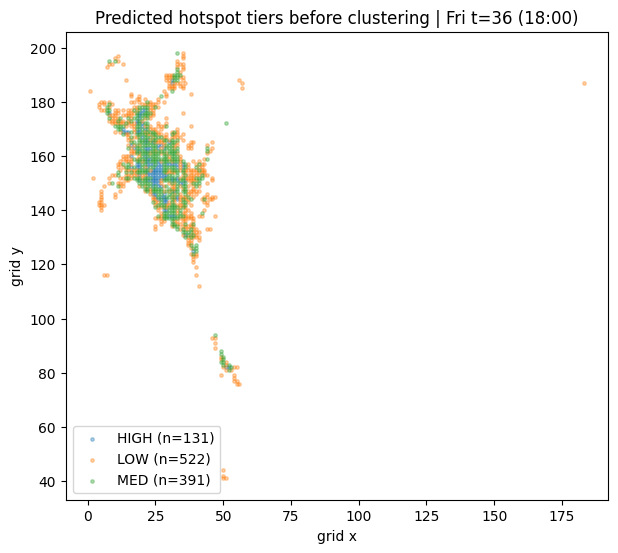

In [41]:
import matplotlib.pyplot as plt

# --- 這段讓圖上能標註時間 ---
weekday_name = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][target_weekday]
time_str = f"{weekday_name} t={target_t} ({target_t//2:02d}:{(target_t%2)*30:02d})"

# 只畫有分級的點（HIGH/MED/LOW）
plot_df = out[out["level"].isin(["HIGH","MED","LOW"])].copy()

fig, ax = plt.subplots(figsize=(7, 7))

for lvl, g in plot_df.groupby("level"):
    ax.scatter(g["x"], g["y"], s=6, alpha=0.35, label=f"{lvl} (n={len(g)})")

ax.set_title(f"Predicted hotspot tiers before clustering | {time_str}")
ax.set_xlabel("grid x")
ax.set_ylabel("grid y")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

In [42]:
import folium
from folium.plugins import MarkerCluster

levels_to_show = ["HIGH","MED","LOW"]  

# 取樣避免 folium 太慢（依你資料量調整）
max_points_to_plot = 1500

pts = out[out["level"].isin(levels_to_show)].copy()
if len(pts) > max_points_to_plot:
    pts = pts.sample(max_points_to_plot, random_state=42)

# grid -> lat/lng
pts_geo = mapper.transform(pts, x_col="x", y_col="y")

m_pts = folium.Map(location=[43.07, 141.35], zoom_start=12)

cluster = MarkerCluster(name="pred_points").add_to(m_pts)

for r in pts_geo.itertuples(index=False):
    folium.CircleMarker(
        location=[r.lat, r.lng],
        radius=2,
        weight=0,
        fill=True,
        fill_opacity=0.6,
        tooltip=f"{weekday_name} {target_t//2:02d}:{(target_t%2)*30:02d} | {getattr(r,'level')} | pred={getattr(r,'pred_count'):.2f}"
    ).add_to(cluster)

m_pts.save("分布點圖.html")